In [1]:
from collections import Counter
from pathlib import Path

import numpy as np

from intrarepresentational_alignment.analysis import analyse_domain_pairs, group_domain_pairs
from intrarepresentational_alignment.data import load_lcc, load_metanet
from intrarepresentational_alignment.embedding import Embedder
from intrarepresentational_alignment.embedding_models import EmbeddingModel
from intrarepresentational_alignment.graph import TopFraction
from intrarepresentational_alignment.similarity import CosineSimilarity, SparseKernel
from intrarepresentational_alignment.viz import (
    plot_cka_bar,
    plot_dense_vs_sparse,
    plot_ged_vs_cka,
    print_alignment_table,
    print_cka_table,
    print_dense_vs_sparse_table,
    print_significance_summary,
    print_summary_table,
)

In [2]:
DATA_PATH      = Path("data/mr-en-20250924142102.rdf")
LCC_PATH       = Path("data/en_small.xml")
MIN_PAIRS      = 8
MAX_PAIRS      = 30
N_PERMS        = 500
EDGE_FRACTION  = 0.15
GED_THRESHOLD  = 0.4
MCS_THRESHOLD  = 0.5
SEED           = 42

## MetaNet


In [3]:
repo = load_metanet(DATA_PATH)
print(f"Loaded  {len(repo.metaphors):,} metaphors, {len(repo.frames):,} frames, "
      f"{len(repo.mappings):,} mappings, {len(repo.examples):,} examples")

http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Closest French frame does not look like a valid URI, trying to serialize this will break.
http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Closest Spanish frame does not look like a valid URI, trying to serialize this will break.
http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Metaphor_Experiential basis does not look like a valid URI, trying to serialize this will break.
http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Related metaphor_Description does not look like a valid URI, trying to serialize this will break.


Loaded  875 metaphors, 951 frames, 645 mappings, 5,616 examples


## LCC Metaphor Corpus


In [4]:
instances = load_lcc(LCC_PATH)
print(f"Loaded {len(instances):,} LCC instances")

all_domain_pairs = group_domain_pairs(instances)
print(f"With explicit source concept (excl. OTHER): {sum(len(v) for v in all_domain_pairs.values()):,} expression pairs")

print(f"Top 15 (source domain -> target domain) pairs:")
pair_counts = Counter({k: len(v) for k, v in all_domain_pairs.items()})
for (src, tgt), n in pair_counts.most_common(15):
    print(f"  {src:<30} -> {tgt:<25} (n={n})")

Loaded 16,265 LCC instances
With explicit source concept (excl. OTHER): 3,336 expression pairs
Top 15 (source domain -> target domain) pairs:
  DISEASE                        -> POVERTY                   (n=43)
  PROTECTION                     -> GUN_RIGHTS                (n=34)
  ABYSS                          -> POVERTY                   (n=22)
  PHYSICAL_LOCATION              -> POVERTY                   (n=22)
  PROTECTION                     -> GUNS                      (n=19)
  STRUGGLE                       -> POVERTY                   (n=18)
  PROTECTION                     -> DEMOCRACY                 (n=18)
  MOVEMENT                       -> CONTROL_OF_GUNS           (n=18)
  PHYSICAL_BURDEN                -> TAXATION                  (n=17)
  MOVEMENT                       -> GOVERNMENT                (n=17)
  MOVEMENT                       -> GUNS                      (n=16)
  ANIMAL                         -> GUNS                      (n=15)
  MOVEMENT                    

## Per-domain CKA experiments


In [5]:
embedder       = Embedder(EmbeddingModel.ALL_MINILM_L6_V2)
selected_pairs = {k: v for k, v in all_domain_pairs.items() if MIN_PAIRS <= len(v) <= MAX_PAIRS}
selected       = sorted(selected_pairs, key=lambda k: len(selected_pairs[k]), reverse=True)
print(f"Domains with {MIN_PAIRS}-{MAX_PAIRS} pairs: {len(selected)}")

domain_results = analyse_domain_pairs(
    selected_pairs, embedder, n_permutations=N_PERMS, 
    ged_threshold=GED_THRESHOLD, mcs_threshold=MCS_THRESHOLD,
    rng=np.random.default_rng(SEED)
)
print_cka_table(domain_results, selected)

Domains with 8-30 pairs: 75
Source domain                Target domain             n     CKA       p
------------------------------------------------------------------------
ABYSS                        POVERTY                  22   0.311   0.010 *
PHYSICAL_LOCATION            POVERTY                  22   0.342   0.004 *
PROTECTION                   GUNS                     19   0.358   0.012 *
STRUGGLE                     POVERTY                  18   0.262   0.924
PROTECTION                   DEMOCRACY                18   0.386   0.034 *
MOVEMENT                     CONTROL_OF_GUNS          18   0.253   0.226
PHYSICAL_BURDEN              TAXATION                 17   0.139   0.590
MOVEMENT                     GOVERNMENT               17   0.460   0.078
MOVEMENT                     GUNS                     16   0.278   0.968
ANIMAL                       GUNS                     15   0.473   0.740
MOVEMENT                     DEMOCRACY                14   0.400   0.234
BUILDING       

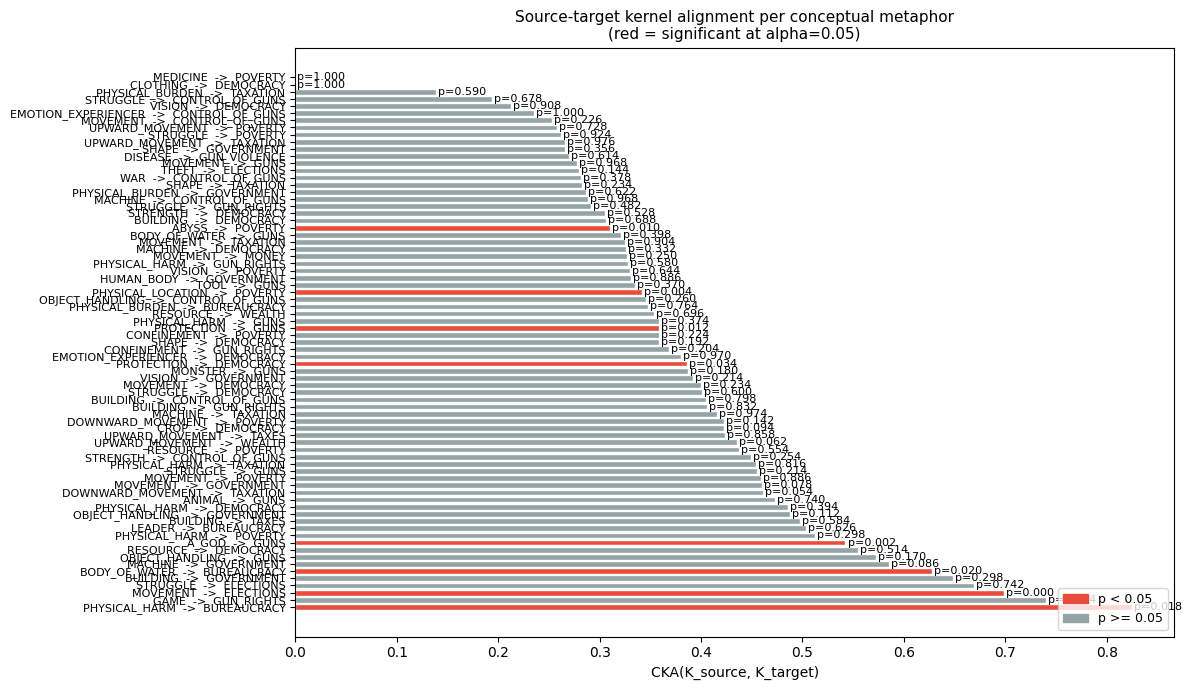

In [6]:
plot_cka_bar(domain_results)

### Graph distance alignment


In [7]:
print_alignment_table(domain_results, selected)

Source domain                Target domain             CKA     GED      WL     MCS   p(CKA)   p(GED)   p(WL)   p(MCS)
---------------------------------------------------------------------------------------------------------------------
ABYSS                        POVERTY                 0.311   0.710   0.411   0.773   0.010*   0.960   0.578    1.000 
PHYSICAL_LOCATION            POVERTY                 0.342   0.255   0.180   0.273   0.004*   1.000   1.000    1.000 
PROTECTION                   GUNS                    0.358   0.320   0.229   0.474   0.012*   0.008*  0.684    1.000 
STRUGGLE                     POVERTY                 0.262   0.543   0.261   0.722   0.924    0.996   1.000    0.974 
PROTECTION                   DEMOCRACY               0.386   0.465   0.118   0.556   0.034*   0.972   0.998    0.662 
MOVEMENT                     CONTROL_OF_GUNS         0.253   0.520   0.286   0.444   0.226    0.240   0.970    1.000 
PHYSICAL_BURDEN              TAXATION                0.1

In [8]:
print_summary_table(domain_results, selected)

Source domain           Target domain              n     CKA   p(CKA)     GED   p(GED)      WL   p(WL)     MCS   p(MCS)
-----------------------------------------------------------------------------------------------------------------------
PHYSICAL_HARM           BUREAUCRACY                8   0.825   0.018*   0.589   0.040*   0.102  0.550    0.250   0.010*
MOVEMENT                ELECTIONS                  9   0.699   0.000*   0.871   0.022*   0.418  0.414    0.667   0.146 
BODY_OF_WATER           BUREAUCRACY                9   0.627   0.020*   0.793   0.038*   0.273  0.298    0.556   0.990 
OBJECT_HANDLING         GUNS                       8   0.572   0.170    0.348   0.002*   0.256  0.752    0.625   1.000 
A_GOD                   GUNS                      11   0.542   0.002*   0.726   0.028*   0.376  0.258    0.727   0.964 
PROTECTION              DEMOCRACY                 18   0.386   0.034*   0.465   0.972    0.118  0.998    0.556   0.662 
PROTECTION              GUNS            

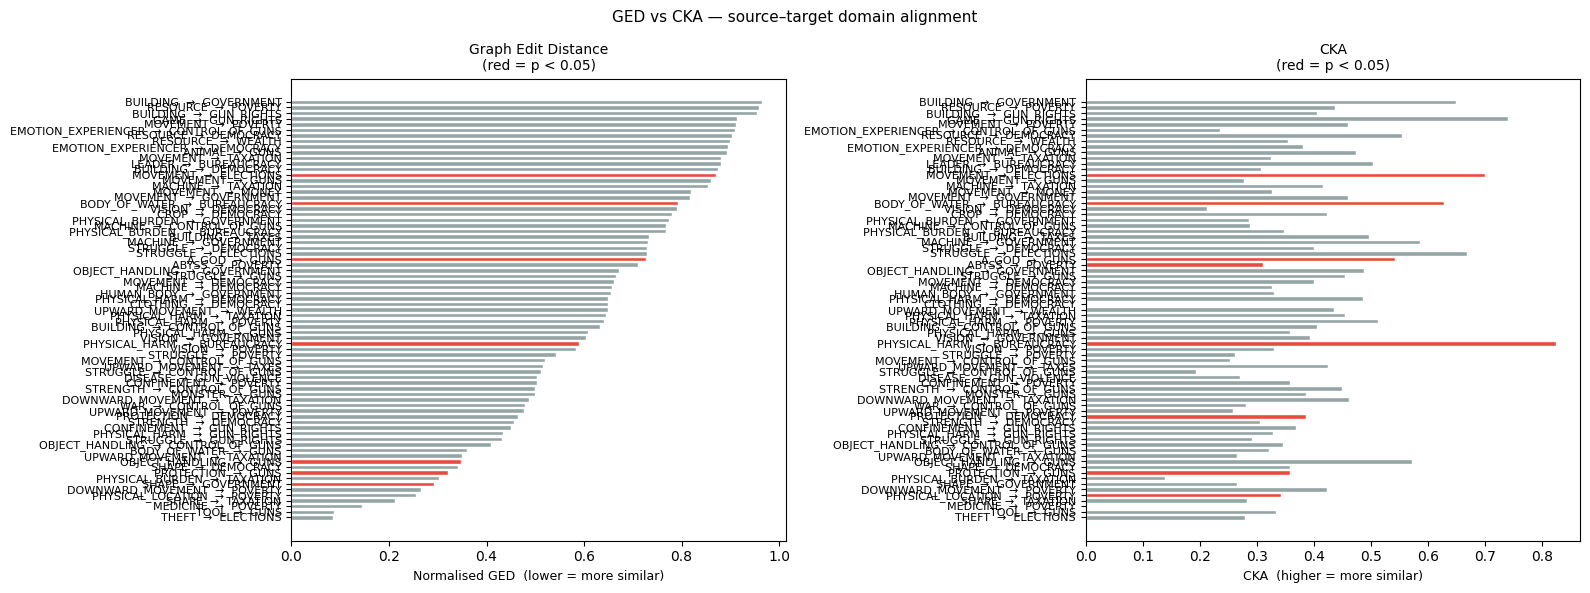

In [9]:
plot_ged_vs_cka(domain_results)

### Sparse kernel


In [10]:
sparse_metric  = SparseKernel(CosineSimilarity(), TopFraction(EDGE_FRACTION))
sparse_results = analyse_domain_pairs(
    selected_pairs, embedder, metric=sparse_metric, n_permutations=N_PERMS,
    rng=np.random.default_rng(SEED)
)
print_dense_vs_sparse_table(domain_results, sparse_results, selected)

Source domain                Target domain          CKA(dense)  CKA(sparse)  p(dense)  p(sparse)
------------------------------------------------------------------------------------------------
ABYSS                        POVERTY                     0.311        0.123     0.010 *      0.058  
PHYSICAL_LOCATION            POVERTY                     0.342        0.181     0.004 *      0.034 *
PROTECTION                   GUNS                        0.358        0.198     0.012 *      0.016 *
STRUGGLE                     POVERTY                     0.262       -0.007     0.924        0.584  
PROTECTION                   DEMOCRACY                   0.386        0.041     0.034 *      0.316  
MOVEMENT                     CONTROL_OF_GUNS             0.253        0.018     0.226        0.480  
PHYSICAL_BURDEN              TAXATION                    0.139        0.106     0.590        0.170  
MOVEMENT                     GOVERNMENT                  0.460        0.014     0.078        0.484 

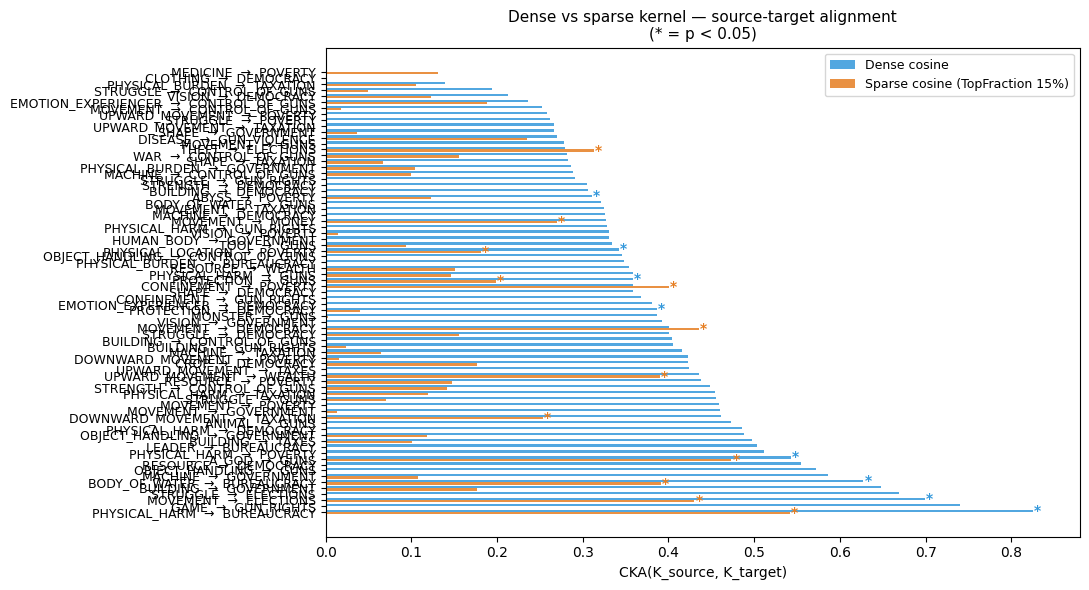

In [11]:
plot_dense_vs_sparse(domain_results, sparse_results, EDGE_FRACTION)

## Significance summary


In [12]:
print_significance_summary(domain_results, sparse_results, selected)

Metric         Dense      Sparse
--------------------------------
CKA                8 / 75          12 / 75
GED                7 / 75          11 / 75
WL                 1 / 75           4 / 75
MCS                1 / 75           1 / 75
--------------------------------
Any               10 / 75          13 / 75
